In [1]:
from src.Elements import Elements
from src.models import create_model 
import torch
import torch.nn as nn

In [2]:

device = "cuda" if torch.cuda.is_available() else "cpu"

model = create_model(model_name="lt_vit")

model.to(device)

print(model)

print(model(torch.tensor([1.0]*4096 * 64).reshape(64, 1, -1).to(device))[0].shape)
pytorch_total_params = sum(p.numel() for p in model.parameters())
print(pytorch_total_params)

LT_VisionTransformer(
  (patch_embed): Conv1d(1, 256, kernel_size=(256,), stride=(256,), bias=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (standard_blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attention): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): TransformerMLP(
        (feedforward): Sequential(
          (0): LazyLinear(in_features=0, out_features=256, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): LazyLinear(in_features=0, out_features=256, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
    )
  )
  (lt_blocks): ModuleList(
    (0-1): 2 x LT_TransformerBlock(
      (norm1_img): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (no

In [3]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/training_data/artificial/X_regression_20250606_190222.npy")
y = np.load("data/training_data/artificial/y_regression_20250606_190222.npy")

print(y[0])

y[y>0] = 1
y[y<=0] = 0
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 160)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 160)


[  0.           0.           0.           0.           0.
   0.          63.22178789   0.           0.           0.
   0.           0.           0.           0.           0.
 181.85966553 162.12221935]


In [5]:
from pathlib import Path
from datetime import datetime 

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


criterion = nn.BCEWithLogitsLoss()
results = EvaluationUtils.train(model, trainloader, testloader, optimizer=optimizer, criterion=criterion, epochs=100, mode="supervised", patience=10)


2025-06-07 12:39:51,596 - INFO - Starting training process (mode: supervised, epochs: 100, patience: 10)
2025-06-07 12:39:51,598 - INFO - Threshold for binary prediction: 0.5


2025-06-07 12:39:51,599 - INFO - --- Epoch 1/100 ---
2025-06-07 12:39:52,795 - INFO -   Batch 10/1407, Loss: 0.1222147
2025-06-07 12:39:53,127 - INFO -   Batch 20/1407, Loss: 0.1080171
2025-06-07 12:39:53,457 - INFO -   Batch 30/1407, Loss: 0.1099132
2025-06-07 12:39:53,788 - INFO -   Batch 40/1407, Loss: 0.1350950
2025-06-07 12:39:54,106 - INFO -   Batch 50/1407, Loss: 0.1218555
2025-06-07 12:39:54,473 - INFO -   Batch 60/1407, Loss: 0.1198567
2025-06-07 12:39:54,823 - INFO -   Batch 70/1407, Loss: 0.1187630
2025-06-07 12:39:55,224 - INFO -   Batch 80/1407, Loss: 0.1330746
2025-06-07 12:39:55,570 - INFO -   Batch 90/1407, Loss: 0.1015485
2025-06-07 12:39:55,905 - INFO -   Batch 100/1407, Loss: 0.1269774
2025-06-07 12:39:56,270 - INFO -   Batch 110/1407, Loss: 0.1068043
2025-06-07 12:39:56,624 - INFO -   Batch 120/1407, Loss: 0.1336258
2025-06-07 12:39:56,989 - INFO -   Batch 130/1407, Loss: 0.1008744
2025-06-07 12:39:57,329 - INFO -   Batch 140/1407, Loss: 0.1257951
2025-06-07 12:39:5

In [6]:
print(results.keys())

dict_keys(['train_loss_history', 'valid_loss_history', 'best_valid_loss', 'best_model_weights', 'metric_histories'])


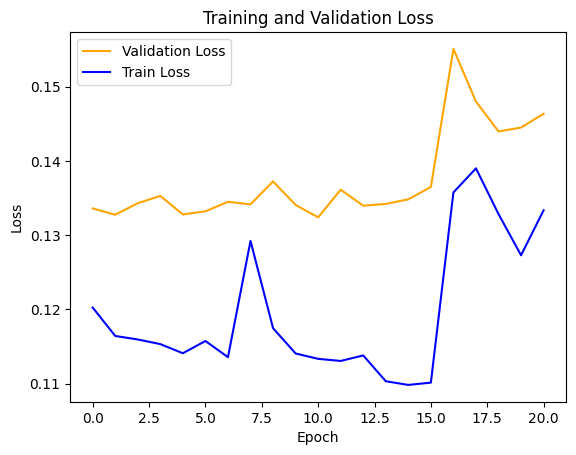

/tmp/ipykernel_1488257/4141164600.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


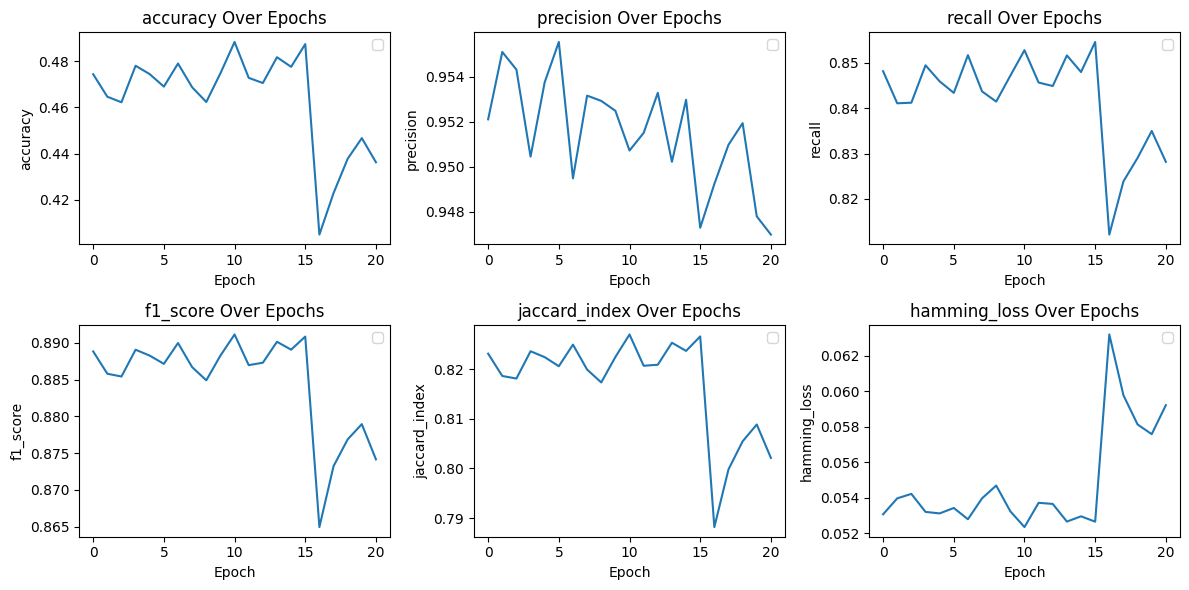

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(results["valid_loss_history"], label="Validation Loss", color="orange")
plt.plot(results["train_loss_history"], label="Train Loss", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

num_metrics = len(results["metric_histories"])
fig, axes = plt.subplots(2, int(num_metrics / 2), figsize=(12, 6))
axes = axes.flatten()

for i, (key, value) in enumerate(results["metric_histories"].items()):
    axes[i].plot(value)
    axes[i].set_title(f"{key} Over Epochs")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel(key)
    axes[i].legend()

plt.tight_layout()

#     print(f"{key}: {value}")

# epochs = range(1, len(metrics[]) + 1)

# fig, axs = plt.subplots(3, 3, figsize=(15, 10))

# axs[0, 0].plot(epochs, train_history, label="Train Loss", color="blue")
# axs[0, 0].plot(epochs, valid_history, label="Validation Loss", color="orange")
# axs[0, 0].set_title("Train vs Validation Loss")
# axs[0, 0].set_xlabel("Epochs")
# axs[0, 0].set_ylabel("Loss")
# axs[0, 0].legend()

# #aaaaaaaaaaaaaaaaaaaaasssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssss Plot F1 Scores
# axs[0, 2].plot(f1_scores, label="F1 Score", color="red")
# axs[0, 2].set_title("F1 Score Over Epochs")
# axs[0, 2].set_xlabel("Epochs")
# axs[0, 2].set_ylim(0, 1)
# axs[0, 2].set_ylabel("F1 Score")

# # Plot Accuracy
# axs[1, 0].plot(accuracies, label="Accuracy", color="purple")
# axs[1, 0].set_title("Accuracy Over Epochs")
# axs[1, 0].set_xlabel("Epochs")
# axs[1, 0].set_ylim(0, 1)
# axs[1, 0].set_ylabel("Accuracy")

# # Plot Recall
# axs[1, 1].plot(recalls, label="Recall", color="brown")
# axs[1, 1].set_title("Recall Over Epochs")
# axs[1, 1].set_xlabel("Epochs")
# axs[1, 1].set_ylim(0, 1)
# axs[1, 1].set_ylabel("Recall")

# # Plot Precision
# axs[1, 2].plot(precisions, label="Precision", color="cyan")
# axs[1, 2].set_title("Precision Over Epochs")
# axs[1, 2].set_xlabel("Epochs")
# axs[1, 2].set_ylim(0, 1)
# axs[1, 2].set_ylabel("Precision")

# axs[2, 0].plot(jaccard_indices, label="Jaccard Indices")
# axs[2, 0].set_title("Jaccard Indices Over Epochs")
# axs[2, 0].set_xlabel("Epochs")
# axs[2, 0].set_ylim(0, 1)
# axs[2, 0].set_ylabel("Jaccard Indices")

# axs[2, 1].plot(hamming_losses, label="Hamming Losses")
# axs[2, 1].set_title("Hamming Losses Over Epochs")
# axs[2, 1].set_xlabel("Epochs")
# axs[2, 1].set_ylim(0, 1)
# axs[2, 1].set_ylabel("Hamming Losses")


# # Adjust layout to avoid overlapping
# plt.tight_layout()
# plt.show()


In [23]:
MODEL_NAME = model.__class__.__name__
torch.save(model, Path(f"data/model_weights/classification/{MODEL_NAME}--{datetime.now().strftime("%Y-%m-%d--%H-%M-%S")}.pt"))

In [37]:
from src.EvaluationUtils import EvaluationUtils
import src.EvaluationUtils
import importlib
importlib.reload(src.EvaluationUtils)

aucs, rocs = src.EvaluationUtils.EvaluationUtils.calculate_roc(model, testloader)

/home/kyre/repos/masters-thesis/env/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1174: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


In [ ]:
from sklearn.metrics import roc_curve, auc

def calculate_roc(model, test_loader):
    model.eval()
    all_real, all_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch)
            all_real.append(y_batch.cpu())
            all_pred.append(y_pred.cpu())

    all_real = torch.cat(all_real).numpy()
    all_pred = torch.cat(all_pred).numpy()
    n_classes = all_real.shape[1]
    aucs = {}
    rocs = {}

    for i in range(n_classes):
        symbol = Elements.NUM2SYMBOL[i]
        fpr, tpr, _ = roc_curve(all_real[:, i], all_pred[:, i])
        roc_auc = auc(fpr, tpr)
        aucs[symbol] = roc_auc
        rocs[symbol] = (fpr, tpr)

    return aucs, rocs

aucs, rocs = calculate_roc(model, testloader)

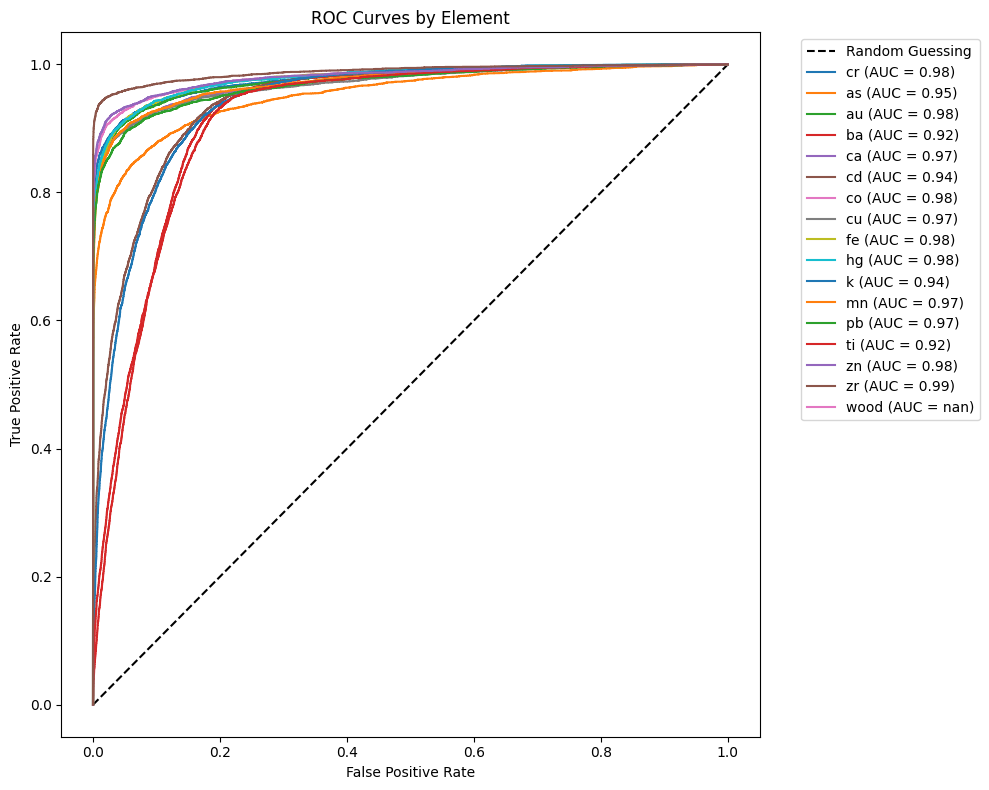

: 

In [ ]:


plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
for element_name in list(Elements.LINES.keys()) + ["wood"]:
    plt.plot(*rocs[element_name], label=f"{element_name} (AUC = {aucs[element_name]:.2f})")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves by Element")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
# plt.savefig("roc_curves.svg")